In [4]:
import numpy as np
import openmc
import openmc.deplete
from pathlib import Path
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt


# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'
# the chain file was downloaded with
# pip install openmc_data
# download_endf_chain -r b8.0
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'


statepoints_folder = Path('statepoints_folder')
Path('statepoints_folder/photons').mkdir(exist_ok=True)
Path('statepoints_folder/neutrons').mkdir(exist_ok=True)
statepoints_folder.mkdir(exist_ok=True)

iron_sphere_radius = 4

# We make a iron material which should produce a few activation products
mat_iron = openmc.Material()
mat_iron.id = 1
mat_iron.add_nuclide("Fe56", 1.0)
mat_iron.add_nuclide("Fe57", 1.0)
mat_iron.set_density("g/cm3", 7.7)
# must set the depletion to True to deplete the material
mat_iron.depletable = True


inner_box = openmc.model.RectangularParallelepiped(
    xmin=-10, xmax=10, ymin=-10, ymax=10, zmin=-10, zmax=10
)

mid_box = openmc.model.RectangularParallelepiped(
    xmin=-11, xmax=11, ymin=-11, ymax=11, zmin=-11, zmax=11
)
outer_box = openmc.model.RectangularParallelepiped(
    xmin=-20, xmax=20, ymin=-20, ymax=20, zmin=-20, zmax=20, boundary_type="vacuum"
)
inner_box_cell = openmc.Cell(region=-inner_box, name='inner box cell')
mid_box_cell = openmc.Cell(region=+inner_box&-mid_box, fill=mat_iron, name='mid box cell')
outer_box_cell = openmc.Cell(region=-outer_box & +mid_box, name='outer box cell')

my_geometry = openmc.Geometry([inner_box_cell, mid_box_cell, outer_box_cell])


my_materials = openmc.Materials([mat_iron])

# 14MeV neutron source that activates material
my_source = openmc.IndependentSource()
my_source.space = openmc.stats.Point((0, 0, 0))
my_source.angle = openmc.stats.Isotropic()
my_source.energy = openmc.stats.Discrete([14.06e6], [1])
my_source.particle = "neutron"

# settings for the neutron simulation(s)
my_neutron_settings = openmc.Settings()
my_neutron_settings.run_mode = "fixed source"
my_neutron_settings.particles = 10000
my_neutron_settings.batches = 10
my_neutron_settings.source = my_source

model_neutron = openmc.Model(my_geometry, my_materials, my_neutron_settings)




/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)


Now we shall plot the model including the source term location

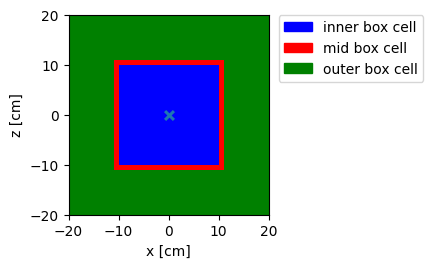

In [ ]:
plot = model_neutron.plot(
    basis='xz',
    n_samples=10,
    color_by="cell",
    legend=True,
    colors={
        inner_box_cell:'blue',
        mid_box_cell:'red',
        outer_box_cell:'green'
    }
)
plt.show()

Create mesh which will be used for material segmentation, activation and gamma sources

In [14]:
regular_mesh = openmc.RegularMesh().from_domain(
    my_geometry, # the corners of the mesh are being set automatically to surround the geometry
    # The combination of 40 and 41 dimensions mean the mesh is perfectly overlapping the geometry
    # in some areas and only partly overlapping in others areas. One of the features of this R2S
    # workflow is that it calculates the material volume in each mesh element and accounts of this
    # when making the source.
    dimension=[40,40,41]
)

# Determine material volumes in each mesh element
vols = regular_mesh.material_volumes(model_neutron, n_samples=10_00_000,max_materials=4)

# Create a MeshMaterialFilter with corresponding bins
mmf = openmc.MeshMaterialFilter.from_volumes(mesh=regular_mesh, volumes=vols)

# This does perform transport but just to get the flux and micro xs
flux_in_each_mesh_voxel, all_micro_xs = openmc.deplete.get_microxs_and_flux(
    model=model_neutron,
    domains=mmf,
    energies=[0,30e6],
    nuclides=my_geometry.get_all_nuclides(),
    chain_file=openmc.config['chain_file']
)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

This section makes a mixed material for each voxel

In [ ]:
all_materials = my_geometry.get_all_materials()
mixed_materials_in_each_mesh_voxel = []
for i in range(regular_mesh.num_mesh_cells):
    mix_fractions = vols.by_element(i)
    materials = []
    fractions = []

    for mat_id, mat_volume in mix_fractions:
        if mat_id is not None:
            material = all_materials[mat_id]
            materials.append(material)
            fractions.append(mat_volume)

    if len(materials) > 0:
        total = sum(fractions)
        normalized = [f / total for f in fractions]
        mixed_material = openmc.Material.mix_materials(
            materials, normalized, 'vo'
        )
        mixed_material.volume = sum(fractions)
        mixed_materials_in_each_mesh_voxel.append(mixed_material)

print(f"made {len(mixed_materials_in_each_mesh_voxel)} materials, one for each voxel in the mesh that overlays a material")

made 3532 materials, one for each voxel in the mesh that overlays a material


In [ ]:
# constructing the operator, note we pass in the flux and micro xs
operator = openmc.deplete.IndependentOperator(
    materials=openmc.Materials(mixed_materials_in_each_mesh_voxel),
    fluxes=[flux[0] for flux in flux_in_each_mesh_voxel],
    micros=all_micro_xs,
    reduce_chain_level=5,
    normalization_mode="source-rate"
)

# This section defines the neutron pulse schedule.
# If the method made use of the CoupledOperator then there would need to be a
# transport simulation for each timestep. However as the IndependentOperator is
# used then just a single transport simulation is done, thus speeding up the
# simulation considerably and is a reasonable approximation as the material burn-up
# is not as large enough to perturb the neutron spectra significant.
# This pulse schedule has 1 second pulses of neutrons then a few hours of cooling steps
timesteps_and_source_rates = [
    (1, 1e18),  # 1 second of 1e18 neutrons/second
    (2*60*60, 0),  # 2 hours and 1 second after shut down
    (2*60*60, 0),  # 4 hours and 1 second after shut down
]

timesteps = [item[0] for item in timesteps_and_source_rates]
source_rates = [item[1] for item in timesteps_and_source_rates]

integrator = openmc.deplete.PredictorIntegrator(
    operator=operator,
    timesteps=timesteps,
    source_rates=source_rates,
    timestep_units='s'
)

# this runs the depletion calculations for the timesteps
# this does the neutron activation simulations and produces a depletion_results.h5 file
integrator.integrate(
    path=statepoints_folder / "neutrons" / "depletion_results.h5"
)

[openmc.deplete] t=0.0 s, dt=1 s, source=1e+18
[openmc.deplete] t=1.0 s, dt=7200 s, source=0.0


/home/jon/openmc/.venv_openmc/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=7201.0 s, dt=7200 s, source=0.0
[openmc.deplete] t=14401.0 (final operator evaluation)


Make dose tally on a regular mesh

In [9]:
# adding a dose tally on a regular mesh
# AP, PA, LLAT, RLAT, ROT, ISO are ICRP incident dose field directions, AP is front facing
energies, pSv_cm2 = openmc.data.dose_coefficients(particle="photon", geometry="AP")
dose_filter = openmc.EnergyFunctionFilter(
    energies, pSv_cm2, interpolation="cubic"  # interpolation method recommended by ICRP
)
particle_filter = openmc.ParticleFilter(["photon"])
mesh_filter = openmc.MeshFilter(regular_mesh)
dose_tally = openmc.Tally()
dose_tally.filters = [mesh_filter, dose_filter, particle_filter]
dose_tally.scores = ["flux"]
dose_tally.name = "photon_dose_on_mesh"

my_gamma_tallies = openmc.Tallies([dose_tally])

Now we have done the neutron activation simulations we can start the work needed for the decay gamma simulations.


In [10]:
my_gamma_settings = openmc.Settings()
my_gamma_settings.run_mode = "fixed source"
my_gamma_settings.batches = 10
my_gamma_settings.particles = 100000

Getting the activated materials from each depletion simulation

Getting gamma decay spectra from the materials (voxelised) and converting to gamma source terms

Creating a mesh source from the gamma source terms

In [11]:
results = openmc.deplete.Results(statepoints_folder / "neutrons" / "depletion_results.h5")

blank_source = openmc.IndependentSource()
blank_source.strength = 0

# this section makes the photon sources from each active material at each
# timestep and runs the photon simulations
# range starts at 1 to skip the first step as that is an irradiation step and there is no activated materials at that stage
for i_cool in range(1, len(timesteps)):
    # we can loop through the materials in each step
    # from the material ID we can get the mesh voxel id
    # then we can 
    # decay gamma source from the stable material at that time
    # also there are no decay products in this first timestep for this model
    photon_sources_for_timestep = []
    strengths_for_timestep = []
    print(f"making photon source for timestep {i_cool}")
    step = results[i_cool]
    print(step.n_mat)
    # activated_mat_ids = step.volume.keys()
    activated_mat_ids = step.index_mat
    # print(activated_mat_ids)
    cumulative_strength_for_time_step = 0 # in Bq
    for activated_mat_id in activated_mat_ids:
        # gets the energy and probabilities for the 
        activated_mat = step.get_material(activated_mat_id)
        energy = activated_mat.get_decay_photon_energy(
            clip_tolerance = 1e-6,  # cuts out a small fraction of the very low energy (and hence negligible dose contribution) photons
            units = 'Bq',
        )
        # print(activated_mat)
        strength = energy.integral()
        cumulative_strength_for_time_step = cumulative_strength_for_time_step +strength
        if strength > 0.:  
            source = openmc.IndependentSource(
                energy=energy,
                particle="photon",
                strength=strength
            )

            photon_sources_for_timestep.append(source)
            strengths_for_timestep.append(strength)

    mesh_indices_with_volumes = [int(i[0]) for i in mmf.bins]
    index_to_obj = dict(zip(mesh_indices_with_volumes, photon_sources_for_timestep))
    photon_sources_for_timestep = [index_to_obj.get(i, blank_source) for i in range(regular_mesh.num_mesh_cells)]

    
    # Make a from the photon sources in this timestep
    # MeshSource documentation https://docs.openmc.org/en/develop/pythonapi/generated/openmc.MeshSource.html
    mesh_source = openmc.MeshSource(
        regular_mesh, photon_sources_for_timestep
    )

    # you have options for the normalization of the source.
    # you could set the mesh_source.strength to the total Bq of all the sources in that time step
    mesh_source.strength = cumulative_strength_for_time_step
    # then use mesh_source.normalize_source_strengths() to update all element source strengths such that they sum to 1.0.
    # or
    # you can leave it so the individual sources have their own strength in Bq
    # perhaps best to experiment here and check the answers, do let me know if you find one option better than the others

    my_gamma_settings.source = mesh_source

    model_gamma = openmc.Model(my_geometry, my_materials, my_gamma_settings, my_gamma_tallies)

    print(f'running gamma transport on stimestep {i_cool}')
    model_gamma.run(cwd=statepoints_folder / "photons" / f"photon_at_time_{i_cool}")


making photon source for timestep 1
3532
running gamma transport on stimestep 1
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 ####

Setting some constants we will use later for unit conversion

In [12]:
# tally.mean is in units of pSv-cm3/source neutron
# multiplication by neutrons_per_pulse changes units to neutron to pSv-cm3/pulse
neutrons_per_pulse = 1e8  # units of neutrons per pulse

# multiplication by pico_to_milli converts from (pico) pSv-cm3/pulse to (milli) mSv-cm3/pulse
pico_to_milli = 1e-9

# dividing by the mesh volume gives the units of mSv/pulse
mesh_voxel_volume = regular_mesh.volumes[0][0][0]

meter_scaled_extent = [i/100 for i in my_geometry.bounding_box.extent['xz']]


Looping through each of the timesteps and plotting a slice of the mesh tally.

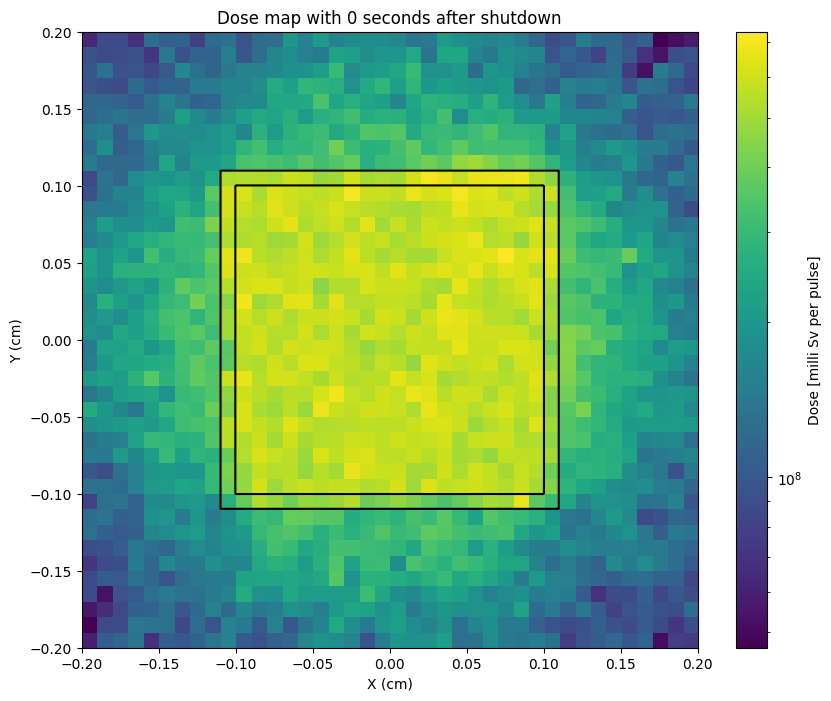

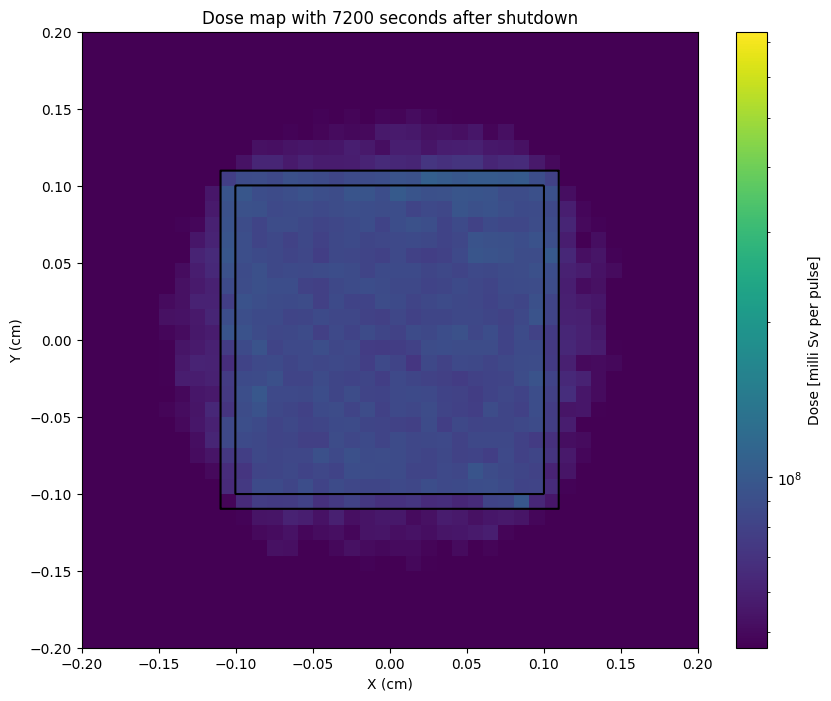

In [ ]:
for i_cool in range(1, len(timesteps)): # skipping the first depletion step as we just want the part where the machine is off for the shut down dose rate
    with openmc.StatePoint(statepoints_folder / "photons" / f"photon_at_time_{i_cool}" / f'statepoint.{my_gamma_settings.batches}.h5') as statepoint:
        my_mesh_tally_result = statepoint.get_tally(name="photon_dose_on_mesh")
        
        # this part of the script plots the images
        tally_slice = my_mesh_tally_result.get_slice(scores=['flux'])

        tally_data = tally_slice.get_reshaped_data(
            expand_dims=True, value='mean'
        ).squeeze()

        # gets a 2d slice of data to later plot
        data_slice = tally_data[:,:,int(regular_mesh.dimension[2]/2)]


        # converts the units
        data_slice = (data_slice * neutrons_per_pulse * pico_to_milli) / mesh_voxel_volume

        if i_cool == 1:
            max_dose = np.max(data_slice)
            min_dose = np.min(data_slice[data_slice > 0])

        # First plot (ax1)
        fig, ax1 = plt.subplots(figsize=(10, 8))
        plot_1 = ax1.imshow(
            np.rot90(data_slice, -1),
            extent=meter_scaled_extent,
            interpolation=None,
            norm=LogNorm(
                vmin=min_dose,  # Smallest non-zero value
                vmax=max_dose,
            ),
        )
        ax1.set_xlabel("X (cm)")
        ax1.set_ylabel("Y (cm)")
        cbar = plt.colorbar(plot_1, ax=ax1)
        cbar.set_label("Dose [milli Sv per pulse]")  # Label for the color bar

        X = np.linspace(meter_scaled_extent[0], meter_scaled_extent[1], data_slice.shape[1])
        Y = np.linspace(meter_scaled_extent[2], meter_scaled_extent[3], data_slice.shape[0])
        X, Y = np.meshgrid(X, Y)

        # Second plot (ax2) overlaid on ax1
        ax2 = my_geometry.plot(
            outline='only',
            basis='xz',
            # extent=my_geometry.bounding_box.extent['xy'],
            axes=ax1,  # Use the same axis as ax1
            color_by='material',
            axis_units='m',
            pixels=10_000_00,  #avoids rounded corners on outline
        )
        ax2.set_title(f"Dose map with {sum(timesteps[1:i_cool])} seconds after shutdown")
        ax2.set_xlim(ax1.get_xlim())
        ax2.set_ylim(ax1.get_ylim())
        ax2.set_aspect(ax1.get_aspect())  # Match aspect ratio

        # Show the combined geometry and dose map plot
        plt.show()

Getting a shut down dose rate map using the R2S method is possible with OpenMC

This method requires more compute compared to the D1S method

One advantage of the R2S method is that the model can be modified between the neutron and photon simulations or between iterations of the photon simulations. This is useful when modeling systems that get activated and then change during the maintanance period. For example a divertor is activated and removed from the machine. The dose emitted can be mapped while it moves around the geometry.

This example covered mesh based R2S simulations, for further reading take a look at this paper which details an early implementation and validation of a cell based R2S method in OpenMC https://iopscience.iop.org/article/10.1088/1741-4326/ad32dd